In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.0 MB/s eta 0:00:00


In [ ]:
import random, numpy as np
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
PATHOGEN_SEEDS = {'Fusarium':'ATGCGT','Botrytis':'CCGATC','Aspergillus':'TTAGGC'}
BENEFICIAL_SEEDS = {'Lactobacillus':'GCTATG','Bacillus':'AATCGG','Pseudomonas':'TTACGA'}
BASES = list('ATGC')
def simulate_read(seed_kmer, length=150):
    read = list(seed_kmer)
    while len(read) < length:
        if random.random() < 0.6:
            read.append(random.choice(list(seed_kmer)))
        else:
            read.append(random.choice(BASES))
    return ''.join(read[:length])
def simulate_sample(class_label, n_reads=500):
    reads = []
    if class_label == 0: # Healthy
        dist = {'Lactobacillus':0.25,'Bacillus':0.20,'Pseudomonas':0.15,
                'Fusarium':0.02,'Botrytis':0.02}
    elif class_label == 1: # Early deteriorating:
        dist = {'Lactobacillus':0.15,'Bacillus':0.10,'Pseudomonas':0.05,
                'Fusarium':0.25,'Botrytis':0.15}
    else: # Advanced deteriorating
        dist = {'Lactobacillus':0.03,'Bacillus':0.02,'Pseudomonas':0.02,
                'Fusarium':0.55,'Botrytis':0.20}
    seeds = {**BENEFICIAL_SEEDS, **PATHOGEN_SEEDS}
    for taxon, prop in dist.items():
        for _ in range(int(n_reads * prop)):
            reads.append(simulate_read(seeds[taxon]))
    random.shuffle(reads)
    return reads
all_samples, all_labels = [], []
for label, count in [(0,500),(1,250),(2,250)]:
    for _ in range(count):
        all_samples.append(simulate_sample(label))
        all_labels.append(label)
print(f'Generated {len(all_samples)} samples.')

Generated 1000 samples.


In [ ]:
from itertools import product
import numpy as np
ALL_KMERS = [''.join(p) for p in product('ATGC', repeat=6)]
KMER_INDEX = {km: i for i, km in enumerate(ALL_KMERS)}
def extract_kmer_freq(reads, k=6):
    vec = np.zeros(len(ALL_KMERS), dtype=np.float32)
    total = 0
    for read in reads:
        for i in range(len(read) - k + 1):
            kmer = read[i:i+k]
            if kmer in KMER_INDEX:
                vec[KMER_INDEX[kmer]] += 1
        total += 1
    if total > 0:
        vec /= total
    return vec
X = np.array([extract_kmer_freq(s) for s in all_samples])
y = np.array(all_labels)
print(f'Feature matrix shape: {X.shape}') # (1000, 4096)
from sklearn.feature_extraction.text import TfidfTransformer
tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X).toarray()
print(f'TF-IDF matrix shape: {X_tfidf.shape}')

Feature matrix shape: (1000, 4096)
TF-IDF matrix shape: (1000, 4096)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
X_train, X_test, y_train, y_test = train_test_split(
X_tfidf, y, test_size=0.2, random_state=42, stratify=y)
X_res, y_res = SMOTE(random_state=42).fit_resample(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, criterion='gini',
max_features='sqrt', class_weight='balanced',
random_state=42, n_jobs=-1)
rf.fit(X_res, y_res)
print(classification_report(y_test, rf.predict(X_test),
target_names=['Healthy','Early','Advanced']))

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       100
       Early       1.00      1.00      1.00        50
    Advanced       1.00      1.00      1.00        50

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
X_tfidf, y, test_size=0.2, random_state=42, stratify=y)
X_res, y_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, criterion='gini',
max_features='sqrt', class_weight='balanced',
random_state=42, n_jobs=-1)
rf.fit(X_res, y_res)
print(classification_report(y_test, rf.predict(X_test),
target_names=['Healthy','Early','Advanced']))

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       100
       Early       1.00      1.00      1.00        50
    Advanced       1.00      1.00      1.00        50

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
import random, numpy as np
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
PATHOGEN_SEEDS = {'Fusarium':'ATGCGT','Botrytis':'CCGATC','Aspergillus':'TTAGGC'}
BENEFICIAL_SEEDS = {'Lactobacillus':'GCTATG','Bacillus':'AATCGG','Pseudomonas':'TTACGA'}
BASES = list('ATGC')
def simulate_read(seed_kmer, length=150):
    read = list(seed_kmer)
    while len(read) < length:
        if random.random() < 0.6:
            read.append(random.choice(list(seed_kmer)))
        else:
            read.append(random.choice(BASES))
    return ''.join(read[:length])
def simulate_sample(class_label, n_reads=500):
    reads = []
    if class_label == 0: # Healthy
        dist = {'Lactobacillus':0.25,'Bacillus':0.20,'Pseudomonas':0.15,
                'Fusarium':0.02,'Botrytis':0.02}
    elif class_label == 1: # Early deteriorating:
        dist = {'Lactobacillus':0.15,'Bacillus':0.10,'Pseudomonas':0.05,
                'Fusarium':0.25,'Botrytis':0.15}
    else: # Advanced deteriorating
        dist = {'Lactobacillus':0.03,'Bacillus':0.02,'Pseudomonas':0.02,
                'Fusarium':0.55,'Botrytis':0.20}
    seeds = {**BENEFICIAL_SEEDS, **PATHOGEN_SEEDS}
    for taxon, prop in dist.items():
        for _ in range(int(n_reads * prop)):
            reads.append(simulate_read(seeds[taxon]))
    random.shuffle(reads)
    return reads
all_samples, all_labels = [], []
for label, count in [(0,500),(1,250),(2,250)]:
    for _ in range(count):
        all_samples.append(simulate_sample(label))
        all_labels.append(label)
print(f'Generated {len(all_samples)} samples.')

Generated 1000 samples.


In [ ]:
!pip install biopython

In [ ]:
from itertools import product
import numpy as np
ALL_KMERS = [''.join(p) for p in product('ATGC', repeat=6)]
KMER_INDEX = {km: i for i, km in enumerate(ALL_KMERS)}
def extract_kmer_freq(reads, k=6):
    vec = np.zeros(len(ALL_KMERS), dtype=np.float32)
    total = 0
    for read in reads:
        for i in range(len(read) - k + 1):
            kmer = read[i:i+k]
            if kmer in KMER_INDEX:
                vec[KMER_INDEX[kmer]] += 1
        total += 1
    if total > 0:
        vec /= total
    return vec
X = np.array([extract_kmer_freq(s) for s in all_samples])
y = np.array(all_labels)
print(f'Feature matrix shape: {X.shape}') # (1000, 4096)
from sklearn.feature_extraction.text import TfidfTransformer
tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X).toarray()
print(f'TF-IDF matrix shape: {X_tfidf.shape}')

Feature matrix shape: (1000, 4096)
TF-IDF matrix shape: (1000, 4096)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
y_cat = to_categorical(y_res, num_classes=3)
ann = Sequential([
    tf.keras.Input(shape=(4096,)), # Using Input(shape) as the first layer
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])
ann.compile(optimizer='adam', loss='categorical_crossentropy',
              metrics=['accuracy'])
ann.fit(X_res, y_cat, epochs=50, batch_size=32,
          validation_split=0.1,
          callbacks=[EarlyStopping(patience=7, restore_best_weights=True)],
          verbose=0)
ann_preds = np.argmax(ann.predict(X_test), axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
X_cnn_train = X_res.reshape(-1, 4096, 1)
X_cnn_test = X_test.reshape(-1, 4096, 1)
cnn = Sequential([
Conv1D(32, kernel_size=3, activation='relu', input_shape=(4096, 1)),
MaxPooling1D(pool_size=2),
Conv1D(64, kernel_size=3, activation='relu'),
MaxPooling1D(pool_size=2),
Flatten(),
Dense(64, activation='relu'),
Dense(3, activation='softmax')
])
cnn.compile(optimizer='adam', loss='categorical_crossentropy',
metrics=['accuracy'])
cnn.fit(X_cnn_train, y_cat, epochs=30, batch_size=32,
validation_split=0.1,
callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
verbose=0)
cnn_preds = np.argmax(cnn.predict(X_cnn_test), axis=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [ ]:
# Reinstall TensorFlow to fix potential library corruption issues
!pip install --upgrade --force-reinstall tensorflow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

X_cnn_train = X_res.reshape(-1, 4096, 1)
X_cnn_test = X_test.reshape(-1, 4096, 1)

cnn = Sequential([
    tf.keras.Input(shape=(4096, 1)), # Using Input(shape) as the first layer
    Conv1D(32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy',
metrics=['accuracy'])

cnn.fit(X_cnn_train, y_cat, epochs=30, batch_size=32,
validation_split=0.1,
callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
verbose=0)

cnn_preds = np.argmax(cnn.predict(X_cnn_test), axis=1)

  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached packaging-26.1-py3-none-any.whl.metadata (3.5 kB)
  Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 

NameError: name 'X_res' is not defined

In [ ]:
history_ann = ann.fit(
    X_res, y_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=7, restore_best_weights=True)],
    verbose=0
)

In [ ]:
history_ann = ann.fit(
    X_res, y_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=7, restore_best_weights=True)],
    verbose=0
)

history_cnn = cnn.fit(
    X_cnn_train, y_cat,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=0
)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
from itertools import product

from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

os.makedirs("output", exist_ok=True)

# --- Code from previous cells to define dependencies ---

# From cell siD-l5SnBK2g: Simulate Data
PATHOGEN_SEEDS = {'Fusarium':'ATGCGT','Botrytis':'CCGATC','Aspergillus':'TTAGGC'}
BENEFICIAL_SEEDS = {'Lactobacillus':'GCTATG','Bacillus':'AATCGG','Pseudomonas':'TTACGA'}
BASES = list('ATGC')
def simulate_read(seed_kmer, length=150):
    read = list(seed_kmer)
    while len(read) < length:
        if random.random() < 0.6:
            read.append(random.choice(list(seed_kmer)))
        else:
            read.append(random.choice(BASES))
    return ''.join(read[:length])
def simulate_sample(class_label, n_reads=500):
    reads = []
    if class_label == 0: # Healthy
        dist = {'Lactobacillus':0.25,'Bacillus':0.20,'Pseudomonas':0.15,
                'Fusarium':0.02,'Botrytis':0.02}
    elif class_label == 1: # Early deteriorating:
        dist = {'Lactobacillus':0.15,'Bacillus':0.10,'Pseudomonas':0.05,
                'Fusarium':0.25,'Botrytis':0.15}
    else: # Advanced deteriorating
        dist = {'Lactobacillus':0.03,'Bacillus':0.02,'Pseudomonas':0.02,
                'Fusarium':0.55,'Botrytis':0.20}
    seeds = {**BENEFICIAL_SEEDS, **PATHOGEN_SEEDS}
    for taxon, prop in dist.items():
        for _ in range(int(n_reads * prop)):
            reads.append(simulate_read(seeds[taxon]))
    random.shuffle(reads)
    return reads
all_samples, all_labels = [], []
for label, count in [(0,500),(1,250),(2,250)]:
    for _ in range(count):
        all_samples.append(simulate_sample(label))
        all_labels.append(label)

# From cell qi6eiSdpBTmo: K-mer Feature Extraction and TF-IDF
ALL_KMERS = [''.join(p) for p in product('ATGC', repeat=6)]
KMER_INDEX = {km: i for i, km in enumerate(ALL_KMERS)}
def extract_kmer_freq(reads, k=6):
    vec = np.zeros(len(ALL_KMERS), dtype=np.float32)
    total = 0
    for read in reads:
        for i in range(len(read) - k + 1):
            kmer = read[i:i+k]
            if kmer in KMER_INDEX:
                vec[KMER_INDEX[kmer]] += 1
        total += 1
    if total > 0:
        vec /= total
    return vec
X = np.array([extract_kmer_freq(s) for s in all_samples])
y = np.array(all_labels)
tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X).toarray()

# From cell L_AHcjJwBt8Y: Random Forest Model
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y)
X_res, y_res = SMOTE(random_state=42).fit_resample(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, criterion='gini',
                            max_features='sqrt', class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(X_res, y_res)

# From cell gVdLxL-dB7qe: ANN Model
y_cat = to_categorical(y_res, num_classes=3)
ann = Sequential([
    tf.keras.Input(shape=(4096,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])
ann.compile(optimizer='adam', loss='categorical_crossentropy',
              metrics=['accuracy'])
history_ann = ann.fit(X_res, y_cat, epochs=50, batch_size=32,
          validation_split=0.1,
          callbacks=[EarlyStopping(patience=7, restore_best_weights=True)],
          verbose=0)
ann_preds = np.argmax(ann.predict(X_test), axis=1)

# From cell HI-V8YftEfM9: CNN Model (using fixed version with Input layer)
X_cnn_train = X_res.reshape(-1, 4096, 1)
X_cnn_test = X_test.reshape(-1, 4096, 1)
cnn = Sequential([
    tf.keras.Input(shape=(4096, 1)),
    Conv1D(32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])
cnn.compile(optimizer='adam', loss='categorical_crossentropy',
metrics=['accuracy'])
history_cnn = cnn.fit(X_cnn_train, y_cat, epochs=30, batch_size=32,
validation_split=0.1,
callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
verbose=0)
cnn_preds = np.argmax(cnn.predict(X_cnn_test), axis=1)

# --- Original code of aAbaJkTUrZ3g starts here ---

label_names = ["Healthy", "Early deteriorating", "Advanced deteriorating"]

# 1) Class distribution
counts = pd.Series(y).value_counts().sort_index()
plt.figure(figsize=(7,5))
sns.barplot(x=label_names, y=counts.values, palette="viridis")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("output/class_distribution.png", dpi=300)
plt.close()

# 2) PCA visualization
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_tfidf.toarray() if hasattr(X_tfidf, "toarray") else X_tfidf)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X2[:,0], X2[:,1], c=y, cmap="viridis", s=25, alpha=0.8)
plt.title("PCA Visualization of Seed Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
handles, _ = scatter.legend_elements()
plt.legend(handles, label_names, title="Classes")
plt.tight_layout()
plt.savefig("output/pca_visualization.png", dpi=300)
plt.close()

# 3) Confusion matrices
models = {
    "Random Forest": rf.predict(X_test),
    "ANN": ann_preds,
    "CNN": cnn_preds
}

for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"output/{name.lower().replace(' ','_')}_confusion_matrix.png", dpi=300)
    plt.close()

# 4) Accuracy summary
acc_data = {
    "Model": ["Random Forest", "ANN", "CNN"],
    "Accuracy": [
        accuracy_score(y_test, models["Random Forest"]),
        accuracy_score(y_test, models["ANN"]),
        accuracy_score(y_test, models["CNN"])
    ]
}
acc_df = pd.DataFrame(acc_data)
acc_df.to_csv("output/model_accuracy_summary.csv", index=False)

plt.figure(figsize=(7,5))
sns.barplot(data=acc_df, x="Model", y="Accuracy", palette="magma")
plt.ylim(0, 1.05)
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.savefig("output/model_accuracy_comparison.png", dpi=300)
plt.close()

# 5) Training history plots if available
if 'history_ann' in globals():
    plt.figure(figsize=(7,5))
    plt.plot(history_ann.history['accuracy'], label='Train Accuracy')
    plt.plot(history_ann.history['val_accuracy'], label='Val Accuracy')
    plt.title("ANN Accuracy Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig("output/ann_accuracy_curve.png", dpi=300)
    plt.close()

if 'history_cnn' in globals():
    plt.figure(figsize=(7,5))
    plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
    plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
    plt.title("CNN Accuracy Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig("output/cnn_accuracy_curve.png", dpi=300)
    plt.close()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


/tmp/ipykernel_19387/1853088767.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_names, y=counts.values, palette="viridis")
/tmp/ipykernel_19387/1853088767.py:192: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=acc_df, x="Model", y="Accuracy", palette="magma")


In [ ]:
if 'y' in locals():
    print(f"'y' is defined with shape: {y.shape}")
else:
    print("'y' is not defined. Please ensure the data preparation cell (qi6eiSdpBTmo or 6233a812) is executed.")

'y' is not defined. Please ensure the data preparation cell (qi6eiSdpBTmo or 6233a812) is executed.


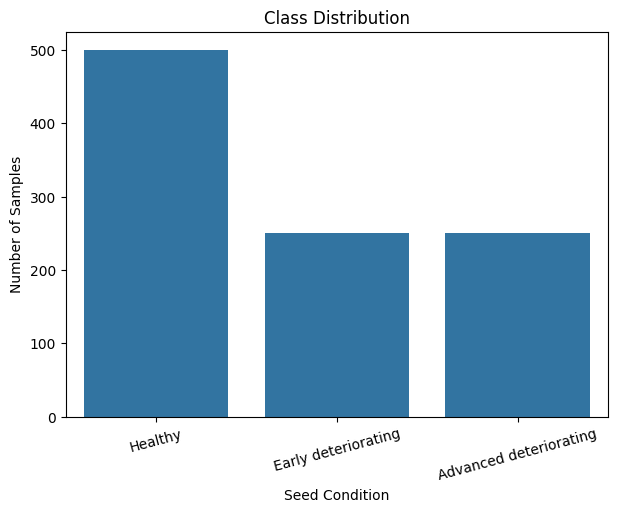

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(x=label_names, y=counts.values)
plt.title("Class Distribution")
plt.xlabel("Seed Condition")
plt.ylabel("Number of Samples")
plt.xticks(rotation=15)
plt.show()

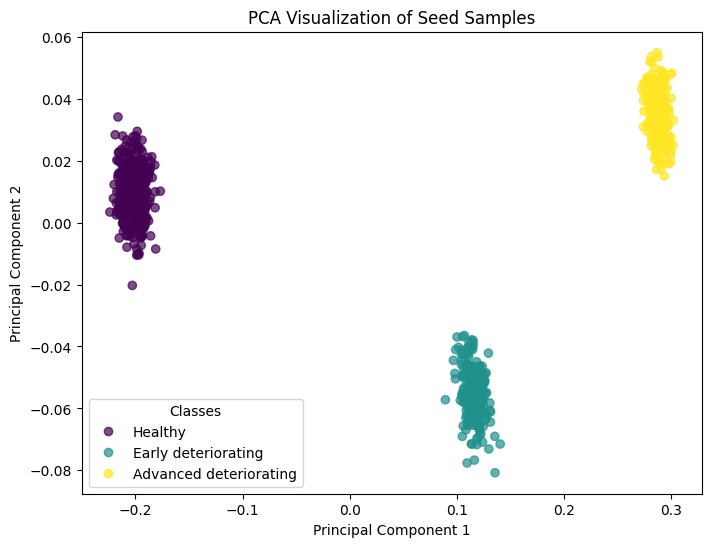

In [ ]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X2[:,0], X2[:,1], c=y, alpha=0.7)
plt.title("PCA Visualization of Seed Samples")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

handles, _ = scatter.legend_elements()
plt.legend(handles, label_names, title="Classes")

plt.show()

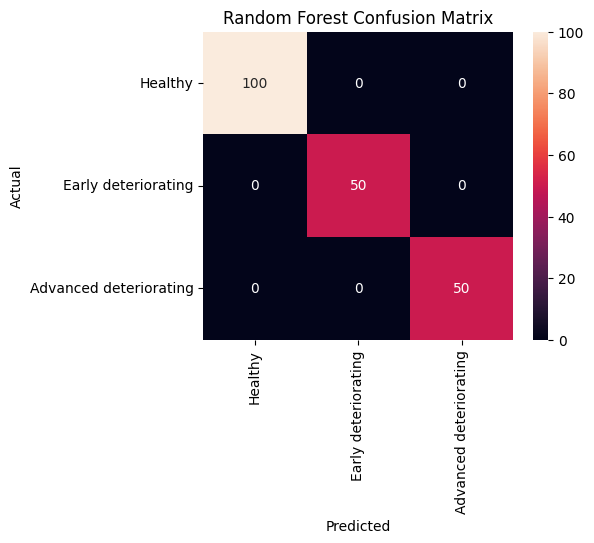

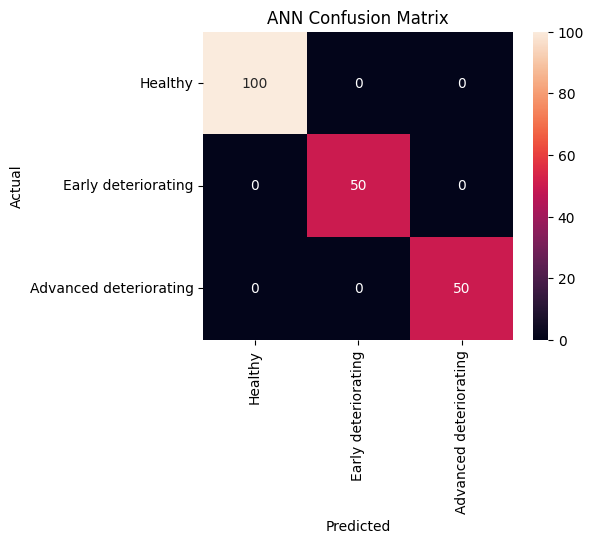

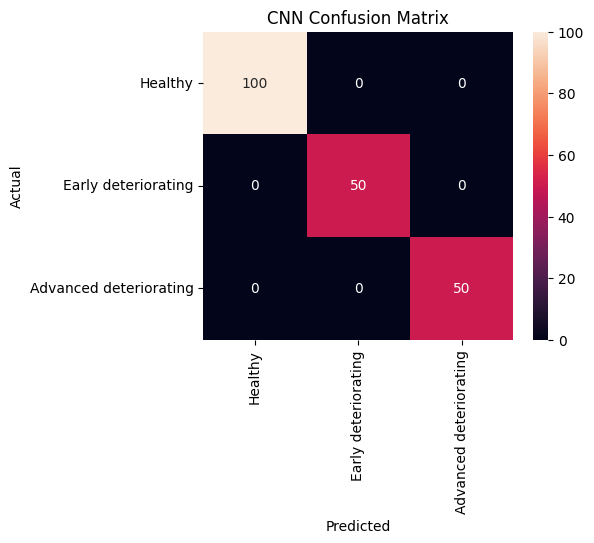

In [ ]:
models = {
    "Random Forest": rf.predict(X_test),
    "ANN": ann_preds,
    "CNN": cnn_preds
}

for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=label_names,
                yticklabels=label_names)

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

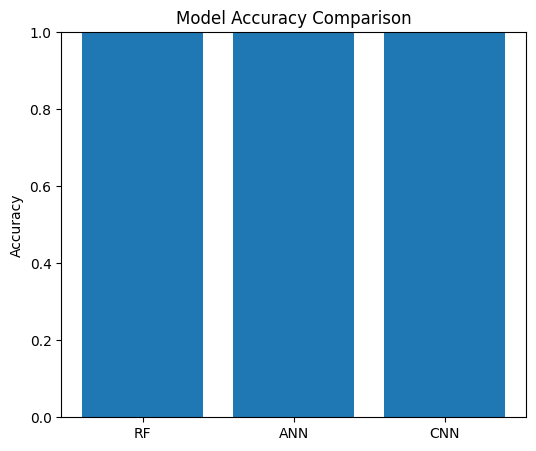

In [ ]:
acc_values = [
    accuracy_score(y_test, models["Random Forest"]),
    accuracy_score(y_test, models["ANN"]),
    accuracy_score(y_test, models["CNN"])
]

plt.figure(figsize=(6,5))
plt.bar(["RF", "ANN", "CNN"], acc_values)
plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

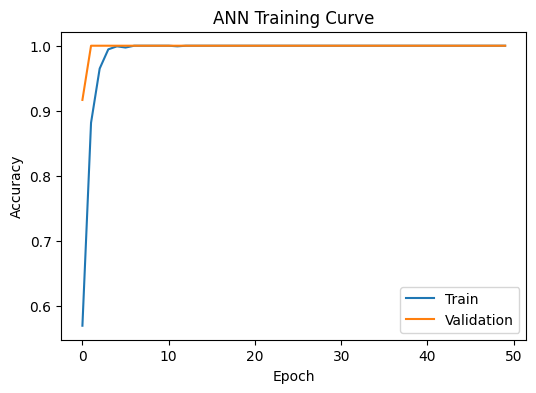

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history_ann.history['accuracy'], label='Train')
plt.plot(history_ann.history['val_accuracy'], label='Validation')
plt.title("ANN Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

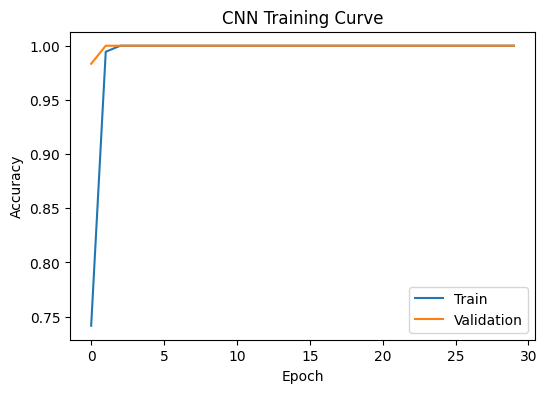

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history_cnn.history['accuracy'], label='Train')
plt.plot(history_cnn.history['val_accuracy'], label='Validation')
plt.title("CNN Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()